In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading Data

In [54]:
df = pd.read_csv("/kaggle/input/iris-dataset/iris.csv")

# Data Description

In [55]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [57]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [58]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Data Visualization

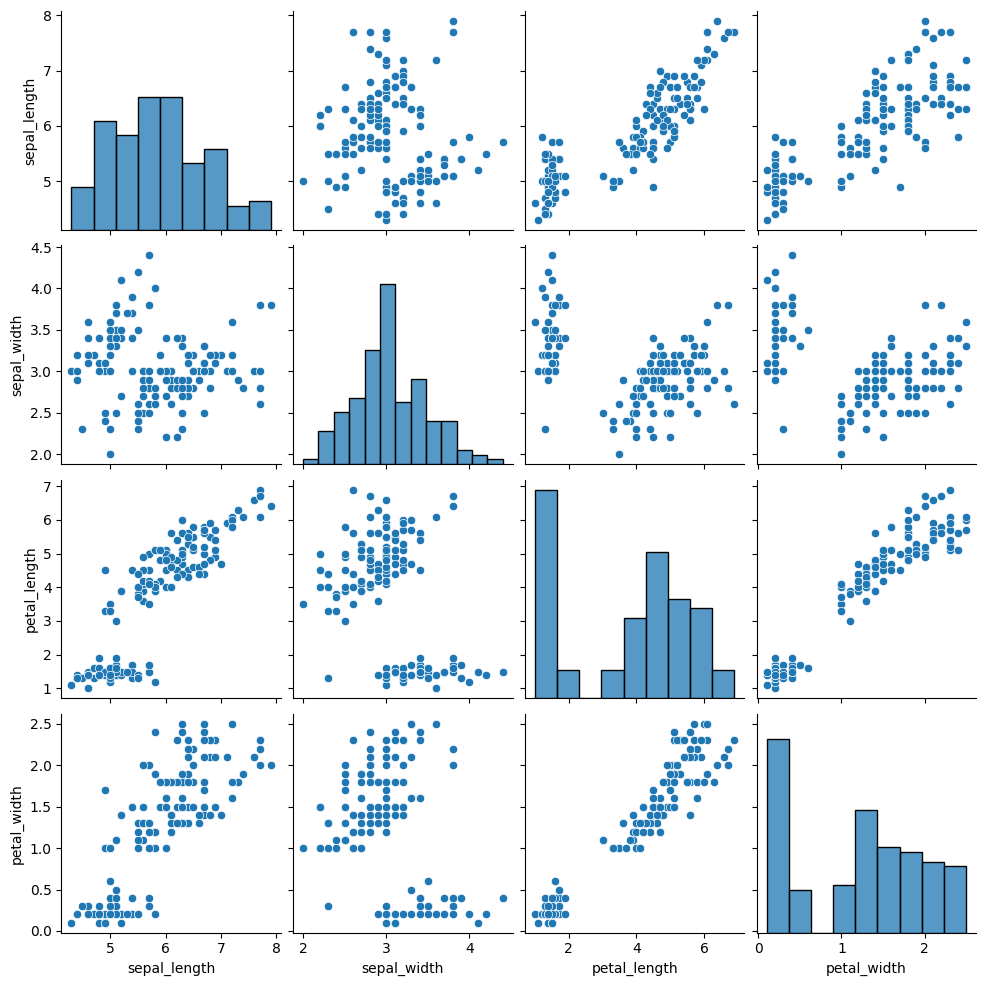

In [59]:
sns.pairplot(df)
plt.show()

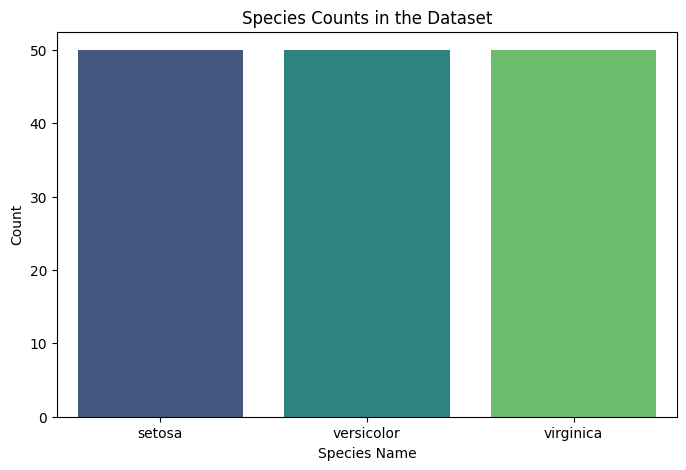

In [60]:
# --- Count Plot ---
plt.figure(figsize=(8, 5))
sns.countplot(x='species', data=df, palette='viridis')

# İngilizce başlık ve eksen isimleri
plt.title('Species Counts in the Dataset')
plt.xlabel('Species Name')
plt.ylabel('Count')

plt.show()

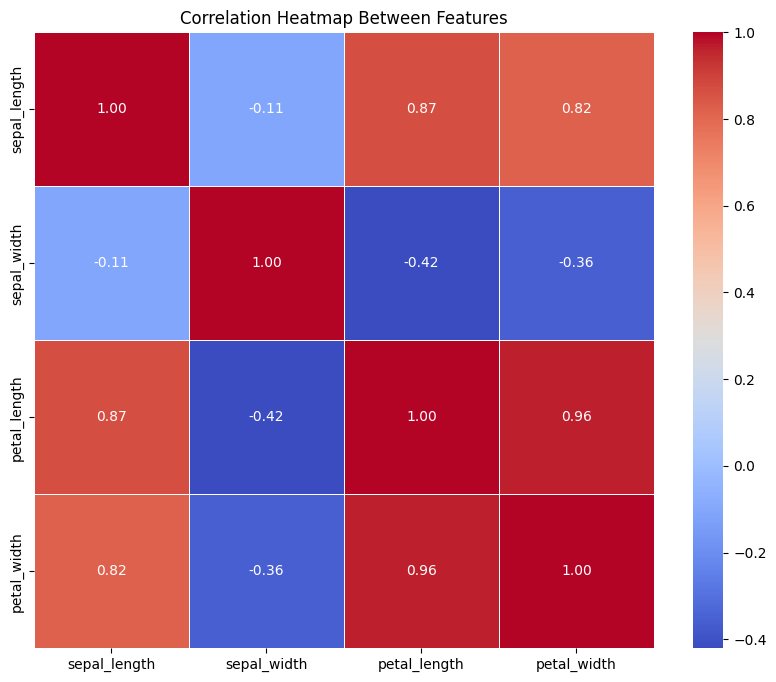

In [61]:
# --- Correlation Heatmap ---
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap Between Features')
plt.show()

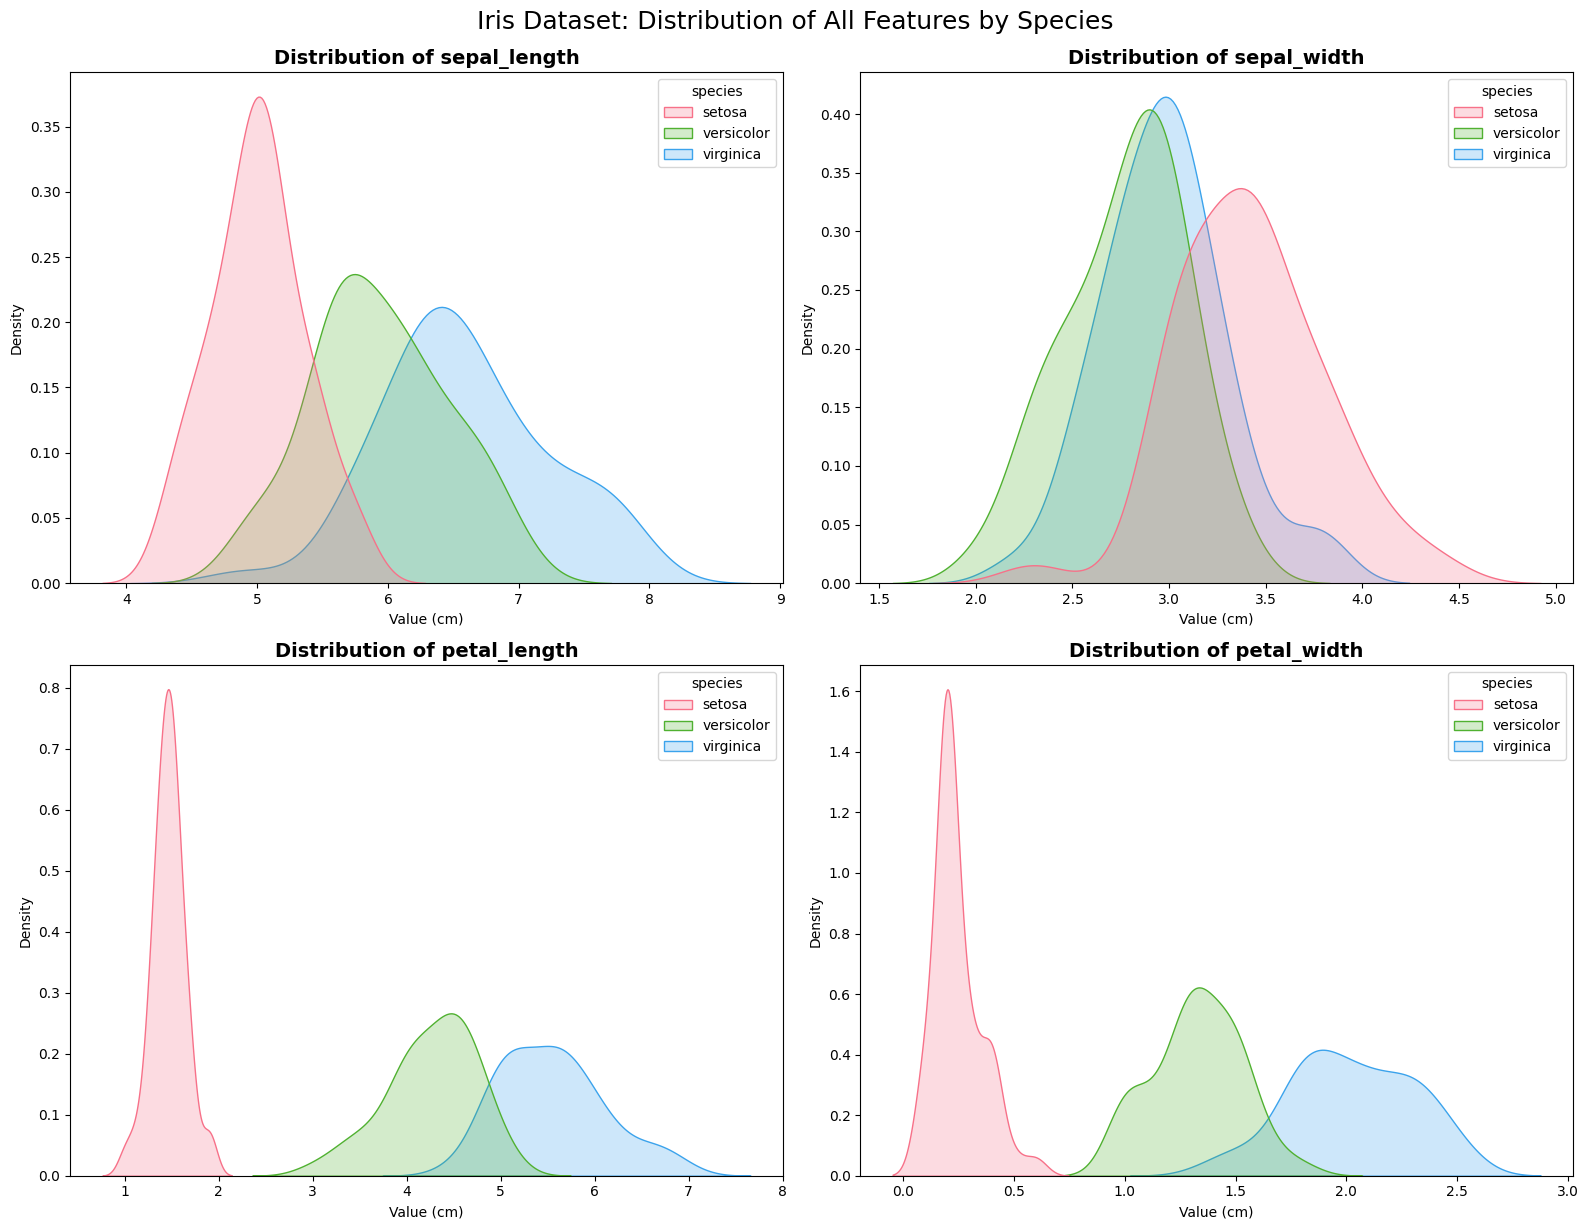

In [62]:

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 2. Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Flatten the axes array for easy iteration in a loop
axes = axes.flatten()

# 3. Create KDE plots for each feature using a loop
for i, feature in enumerate(features):
    sns.kdeplot(
        data=df, 
        x=feature, 
        hue="species", 
        fill=True, 
        palette="husl", 
        ax=axes[i] # Assigns the plot to the specific subplot box
    )
    axes[i].set_title(f'Distribution of {feature}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Value (cm)')
    axes[i].set_ylabel('Density')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.suptitle('Iris Dataset: Distribution of All Features by Species', fontsize=18, y=1.02)
plt.show()

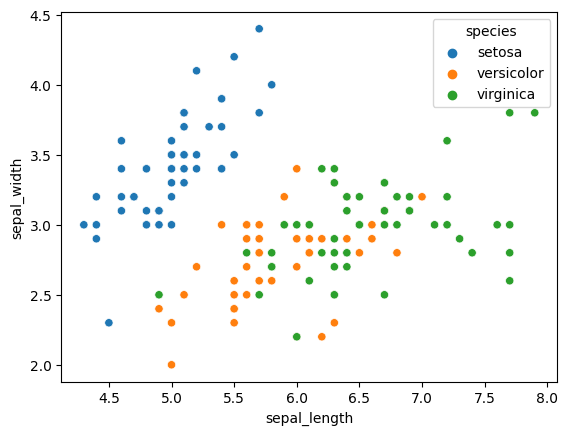

In [63]:
# --- scatter plot ---
sns.scatterplot(x=df["sepal_length"], y=df["sepal_width"], hue=df["species"])
plt.show()

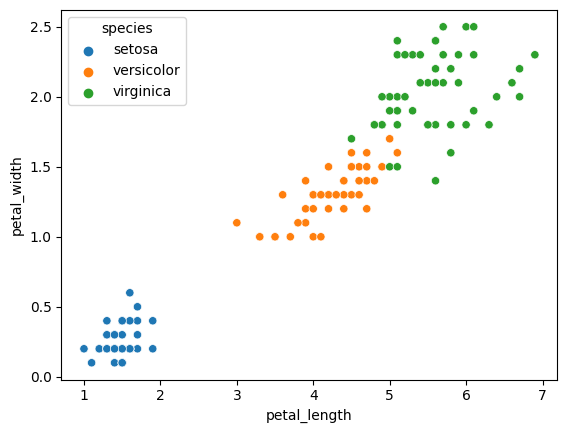

In [64]:
sns.scatterplot(x=df["petal_length"], y=df["petal_width"], hue=df["species"])
plt.show()

# Encoding 

In [65]:
# --- Label encoding ---
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df["species"] = label_encoder.fit_transform(df["species"])

In [66]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [67]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [68]:
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

In [69]:
X = df.drop("species", axis=1)
y = df["species"]

In [70]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

# Logistic Regression Classification

In [71]:
# --- Logicstic Regression ---
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
#hyperparameter tuning with class weights to handle imbalance
penalty=['l1', 'l2', 'elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

params=dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)

In [72]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)
grid.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(),
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy')

In [73]:
grid.best_params_

{'C': 100, 'class_weight': {0: 100, 1: 1}, 'penalty': 'l2', 'solver': 'sag'}

In [74]:
y_pred=grid.predict(X_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
score=accuracy_score(y_pred,y_test)
print("score: ", score)
print(classification_report(y_pred,y_test))
print("confusion matrix: \n " , confusion_matrix(y_pred,y_test))

score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

confusion matrix: 
  [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]


# Support Vector Classification (SVC)

In [75]:
# --- SVC ---
from sklearn.svm import SVC
svc=SVC(kernel='linear')
svc.fit(X_train,y_train)

SVC(kernel='linear')

In [76]:
y_pred2=svc.predict(X_test)

from sklearn.metrics import classification_report,confusion_matrix

score=accuracy_score(y_pred2,y_test)
print("score: ", score)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

score:  0.9736842105263158
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.92      1.00      0.96        12

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

[[12  0  0]
 [ 0 13  1]
 [ 0  0 12]]


In [77]:
from sklearn.model_selection import GridSearchCV
 
# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5)
grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']})

In [78]:
grid.best_params_

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

In [79]:
y_pred2=grid.predict(X_test)
score=accuracy_score(y_pred2,y_test)
print("score: ", score)
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))

score:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

[[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]


# Naive Bayes Classification

In [80]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
gnb = GaussianNB()

gnb.fit(X_train, y_train)
y_pred3 = gnb.predict(X_test)

print("confusion matrix: \n", confusion_matrix(y_pred3, y_test))
print("accuracy score: ", accuracy_score(y_pred3, y_test))
print("classification report: ", classification_report(y_pred3, y_test))

confusion matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
accuracy score:  1.0
classification report:                precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

